### 代码块 1：MLP 前向传播

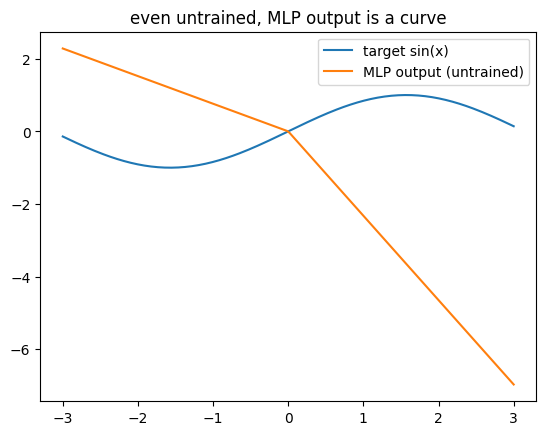

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- 激活函数 ----------
def relu(z):
    return np.maximum(0, z)      # 逐元素取 max(0, z)

# ---------- 造一个"弯的"目标：正弦曲线（线性模型学不了）----------
np.random.seed(0)
X = np.linspace(-3, 3, 200).reshape(-1, 1)   # 形状 (200,1)
y_true = np.sin(X)                           # 目标曲线

# ---------- 定义一个单隐藏层 MLP 的参数（先随机初始化，Day5 再训练）----------
d_in, d_hidden, d_out = 1, 16, 1
W1 = np.random.randn(d_in, d_hidden)         # (1,16)
b1 = np.zeros((1, d_hidden))                 # (1,16)
W2 = np.random.randn(d_hidden, d_out)        # (16,1)
b2 = np.zeros((1, d_out))                    # (1,1)

# ---------- 前向传播 ----------
def mlp_forward(X):
    z1 = X @ W1 + b1     # 线性层1: (200,1)@(1,16) -> (200,16)
    a1 = relu(z1)        # 非线性激活: (200,16)
    z2 = a1 @ W2 + b2    # 输出层:   (200,16)@(16,1) -> (200,1)
    return z2

y_pred = mlp_forward(X)

plt.plot(X, y_true, label="target sin(x)")
plt.plot(X, y_pred, label="MLP output (untrained)")
plt.legend(); plt.title("even untrained, MLP output is a curve")
plt.show()

### 代码块 2：可视化三种激活函数和它们的导数

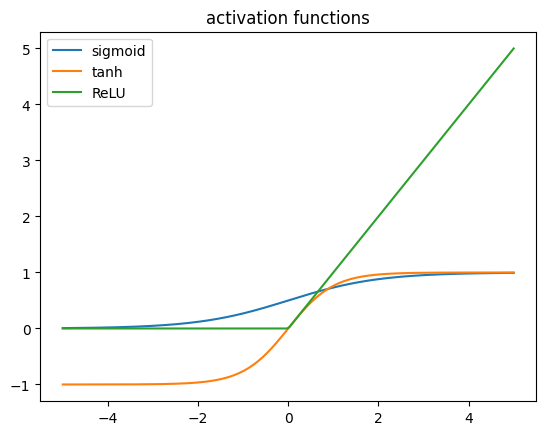

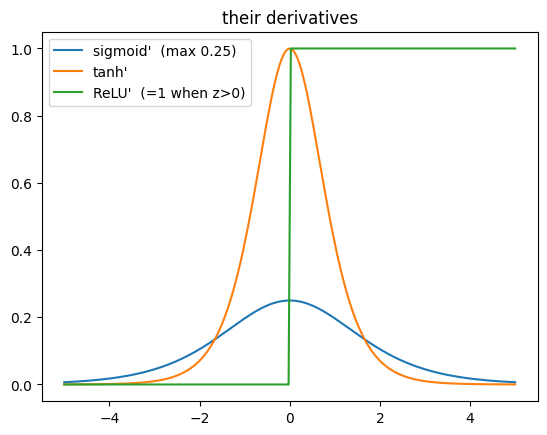

In [2]:
def sigmoid(z): return 1/(1+np.exp(-z))
z = np.linspace(-5, 5, 200)

# 函数本身
plt.plot(z, sigmoid(z), label="sigmoid")
plt.plot(z, np.tanh(z), label="tanh")
plt.plot(z, relu(z),    label="ReLU")
plt.legend(); plt.title("activation functions"); plt.show()

# 它们的导数
plt.plot(z, sigmoid(z)*(1-sigmoid(z)), label="sigmoid'  (max 0.25)")
plt.plot(z, 1 - np.tanh(z)**2,         label="tanh'")
plt.plot(z, (z > 0).astype(float),     label="ReLU'  (=1 when z>0)")
plt.legend(); plt.title("their derivatives"); plt.show()